In [16]:
import scanpy as sc
import decoupler as dc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gseapy as gp
import textwrap


In [17]:
sns.set_context("paper", font_scale=1.25) # set some nice global plotting settings.
plt.rcParams["figure.dpi"] = 300  # High-resolution output


# Subset immune selection just for Kupffer cells

In [3]:
adata = sc.read_h5ad('/share/crsp/lab/seyedam/share/ER_EA/8cube_immunecells/annotated_data_17_36.h5ad')
adata.obs['state'] = adata.obs['state'].replace('Tissue-Remodeling', 'Tissue_Remodeling')
adata = adata[adata.obs['Genotype'] != 'TREM2R47HNSS_HO']

kc_adata = adata[adata.obs['cell_type'] == 'Kupffer cells']
kc_adata.obs['leiden'] = kc_adata.obs['leiden'].astype(str)


/tmp/ipykernel_63051/1314335841.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['state'] = adata.obs['state'].replace('Tissue-Remodeling', 'Tissue_Remodeling')
/tmp/ipykernel_63051/1314335841.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  kc_adata.obs['leiden'] = kc_adata.obs['leiden'].astype(str)


# Fig. S6a

In [6]:
# https://www.sciencedirect.com/science/article/pii/S1074761321003368?via%3Dihub
# https://www.sciencedirect.com/science/article/pii/S1074761321002119?via%3Dihub

marker_genes_dict = {
    "KC": ['Clec4f','Lyz2','Vsig4','Csf1r'],
    "KC1": ['Timd4','Ptprc','Adgre1','H2-Ab1'],
    "KC2": ['Mrc1','Esam','Pecam1','Clec4g','Fcgr2b','Flt1','Flt4','Kdr','Tie1','Il2ra','Il2rb','Il2rg'],
}



... storing 'leiden' as categorical


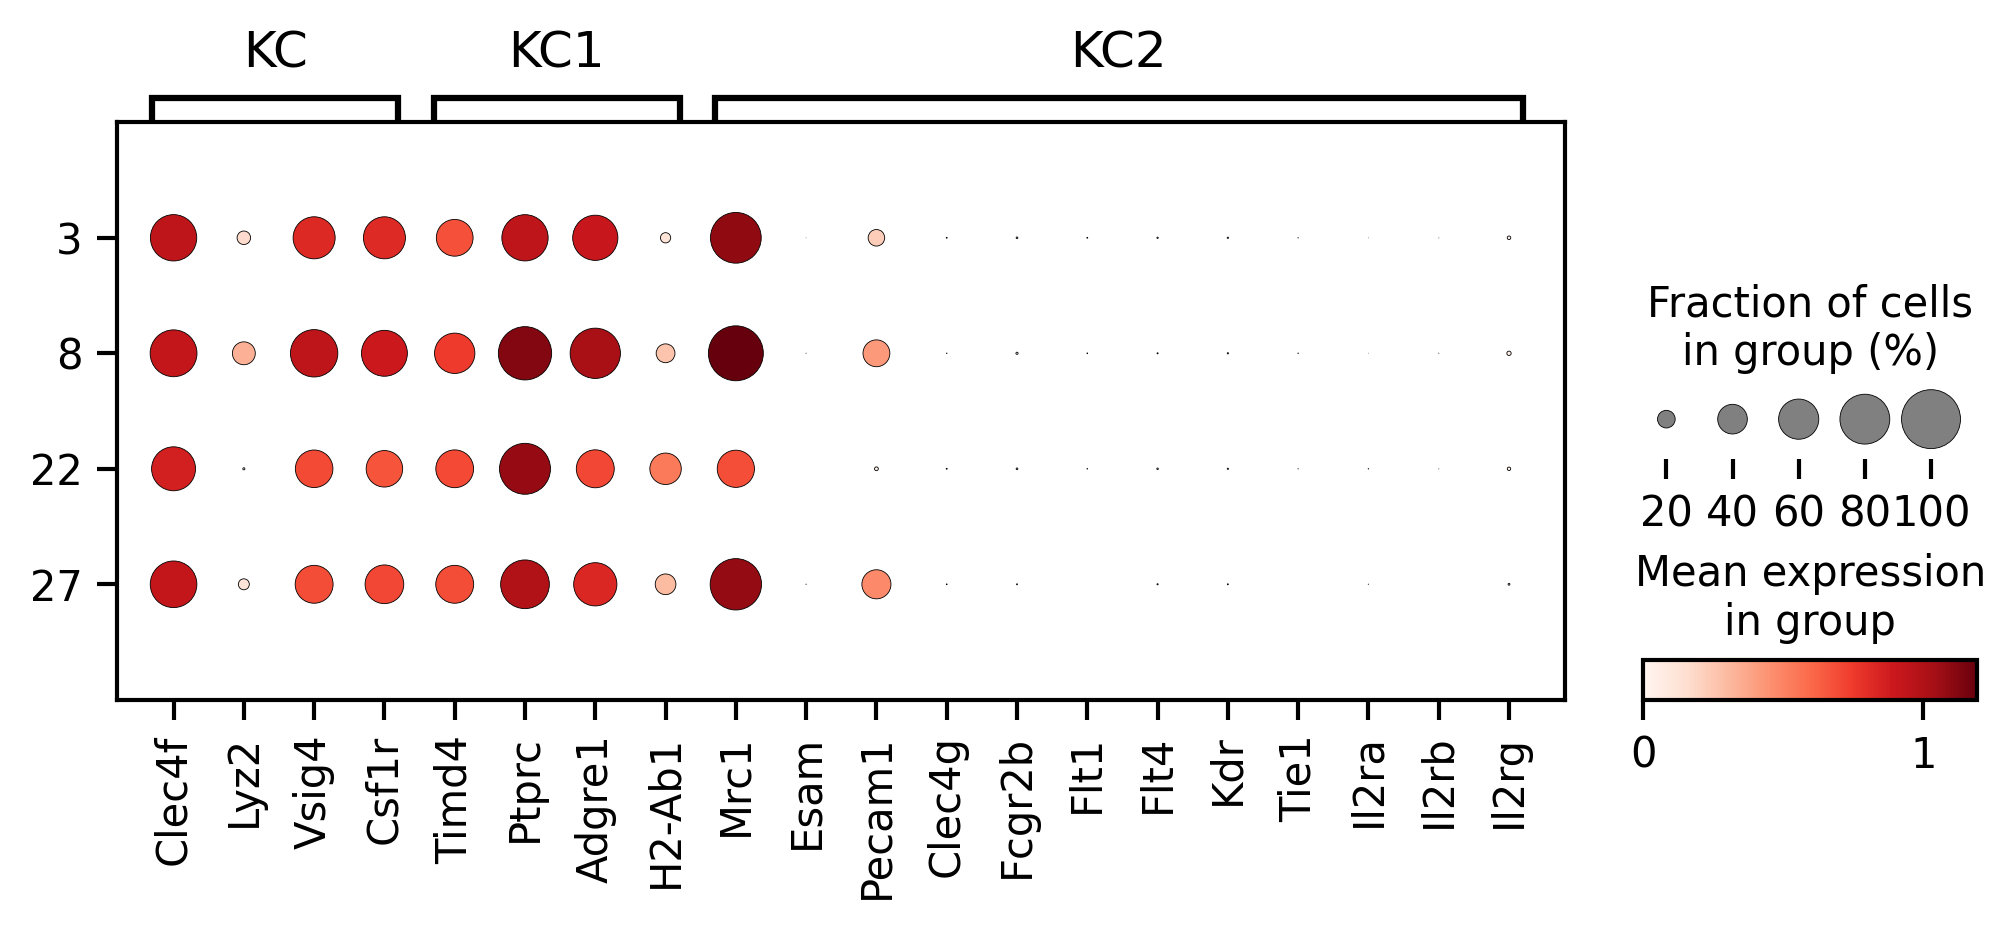

In [5]:
sc.pl.dotplot(kc_adata, marker_genes_dict, 'leiden',
              #mean_only_expressed = True,
              figsize = (8,2.5),
              log = True,
              dendrogram=False)


# Fig. S6b

## DEGs

In [8]:
sc.tl.rank_genes_groups(kc_adata, groupby="leiden", method="wilcoxon")


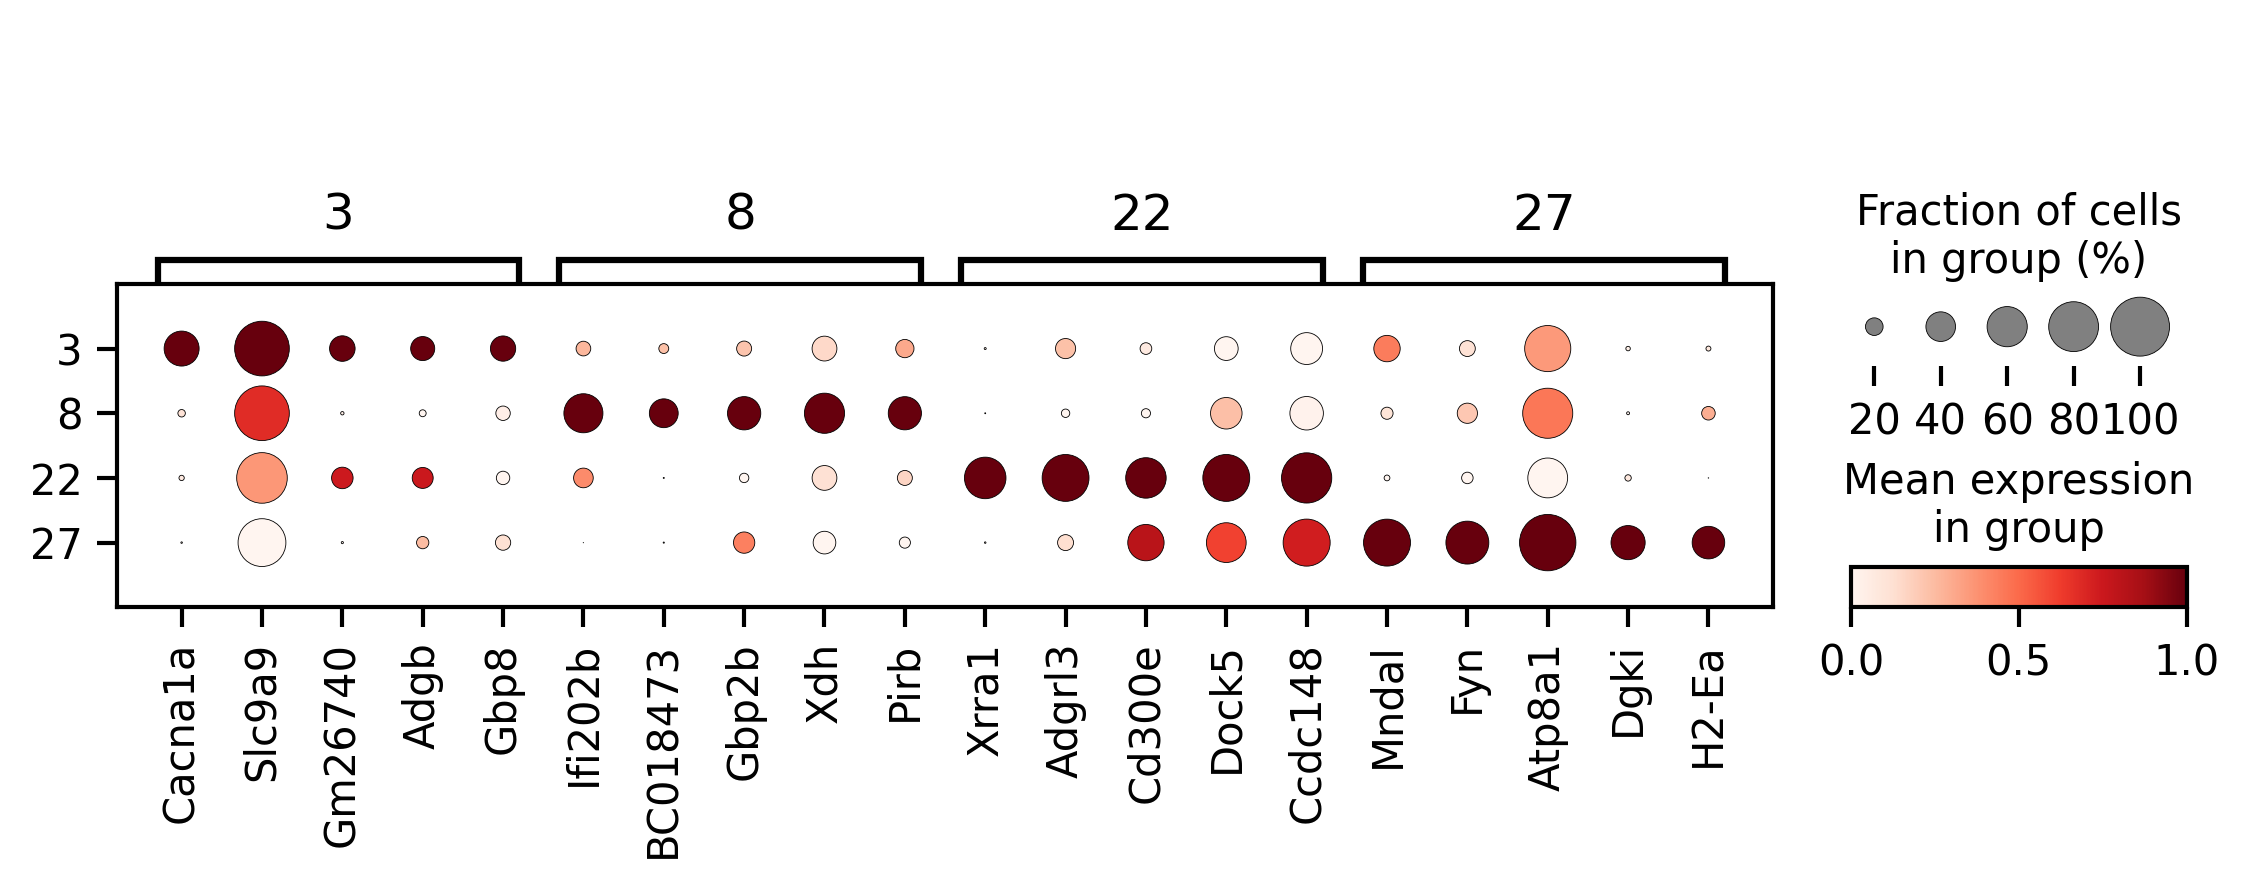

In [9]:
sc.pl.rank_genes_groups_dotplot(
    kc_adata, groupby="leiden", standard_scale="var", n_genes=5, dendrogram = False
)

In [10]:
df = sc.get.rank_genes_groups_df(kc_adata, group="8")


In [11]:
df_up  = df[(df['logfoldchanges'] > 0.5) & (df['pvals_adj'] < 0.01)]
df_down  = df[(df['logfoldchanges'] < -1) & (df['pvals_adj'] < 0.01)]

In [12]:
genes = df_up['names'].unique().tolist()

In [13]:
len(genes)

353

In [18]:
enr = gp.enrichr(
    gene_list=genes,
    organism='Mouse', 
    gene_sets=['Reactome_2022', 'GO_Biological_Process_2023']
)
df = enr.results
df = df.sort_values(by="Adjusted P-value", ascending=True)

df['-log10(Adjusted P-value)'] = -np.log10(df['Adjusted P-value'])
df = df[df['Adjusted P-value'] <= 0.01]
df = df.head(5)
df['Term'] = df['Term'].str.replace("Tumor Necrosis Factor", "TNF", regex=False)


# Fig. S6b

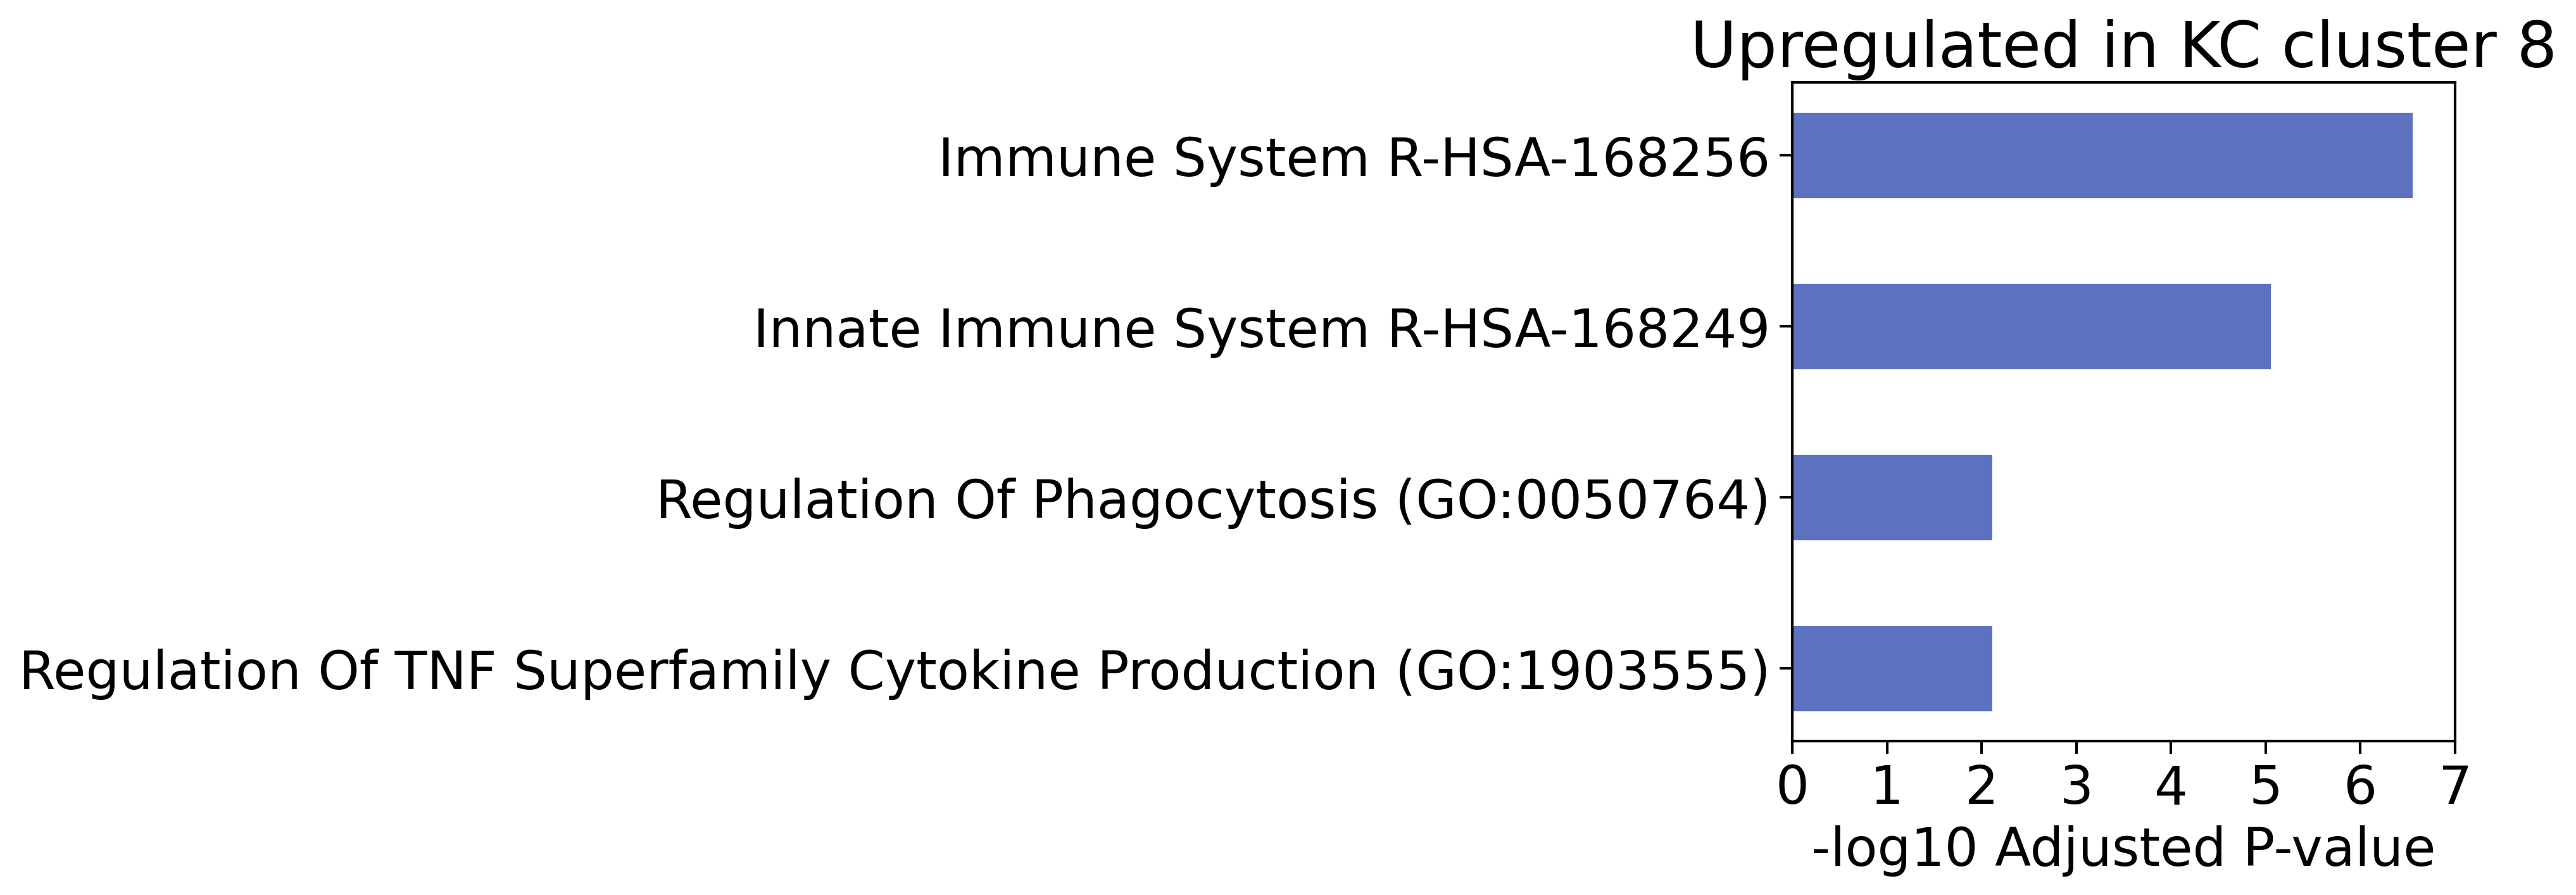

In [19]:
# Plot
plt.figure(figsize=(4.5, 4.5))
plt.barh(df['Term'], df['-log10(Adjusted P-value)'], color='#5C72BF', height = 0.5)
plt.xlabel('-log10 Adjusted P-value', fontsize=20)
plt.ylabel('')
plt.title('Upregulated in KC cluster 8', fontsize = 24)
plt.gca().invert_yaxis() 

plt.xticks(np.arange(0, df['-log10(Adjusted P-value)'].max() + 1, 1))
plt.yticks(fontsize=20) 
plt.xticks(fontsize=20)

plt.show()

In [22]:
df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,-log10(Adjusted P-value)
0,Reactome_2022,Immune System R-HSA-168256,73/1943,3.527408e-10,2.776070e-07,0,0,2.478459,53.944368,CD86;APP;PYGB;CSF3R;SH3KBP1;PROS1;PIK3CB;CTSS;...,6.556570
1,Reactome_2022,Innate Immune System R-HSA-168249,45/1035,2.249184e-08,8.850537e-06,0,0,2.753394,48.487587,APP;PYGB;CFH;CLEC12A;PROS1;PIK3CB;MEFV;CTSS;IF...,5.053030
788,GO_Biological_Process_2023,Regulation Of Phagocytosis (GO:0050764),8/58,7.727815e-06,7.731678e-03,0,0,9.088464,106.977439,FGR;HCK;IL15;CLEC7A;SLC11A1;SIRPA;CD47;TGM2,2.111726
787,GO_Biological_Process_2023,Regulation Of TNF Superfamily Cytokine Product...,4/8,6.314868e-06,7.731678e-03,0,0,56.283668,673.862048,CX3CR1;MAPKAPK2;SIRPA;CD47,2.111726


In [20]:
# Create an empty set to store unique genes
unique_genes = set()

# Iterate through each row in the 'Genes' column, split by ';', and update the set
df['Genes'].dropna().apply(lambda x: unique_genes.update(x.split(";")))

# Convert to a sorted list (optional)
unique_genes_sorted = sorted(unique_genes)

# Display the unique genes
print(unique_genes_sorted)


['ABI1', 'ADGRE5', 'AP1S2', 'APP', 'ARSB', 'ATG7', 'ATP6V1E1', 'ATP7A', 'BCL2', 'BIN2', 'BIRC3', 'C1QC', 'CASP8', 'CCM2', 'CD274', 'CD47', 'CD86', 'CFH', 'CLEC12A', 'CLEC1B', 'CLEC7A', 'CSF2RA', 'CSF2RB', 'CSF3R', 'CTSC', 'CTSH', 'CTSS', 'CX3CR1', 'CYBB', 'FGR', 'FLNA', 'HCK', 'HMOX2', 'ICOS', 'IFIH1', 'IFNGR1', 'IKBKE', 'IL15', 'IL17RA', 'IL18BP', 'IRAK3', 'ITGA4', 'LCP2', 'LGALS3', 'LILRA5', 'MANBA', 'MAP3K8', 'MAPKAPK2', 'MCL1', 'MEFV', 'MRC1', 'MSN', 'MYO10', 'NUP98', 'P2RX7', 'PECAM1', 'PELI1', 'PIK3CB', 'PRKCB', 'PROS1', 'PTK2B', 'PYGB', 'RNF213', 'RSAD2', 'SAMHD1', 'SDCBP', 'SH3KBP1', 'SIRPA', 'SLC11A1', 'STAT2', 'TGM2', 'TLR8', 'TRPM2', 'VAV2', 'XDH']


# Fig. S6c
Selected genes from significant GO terms

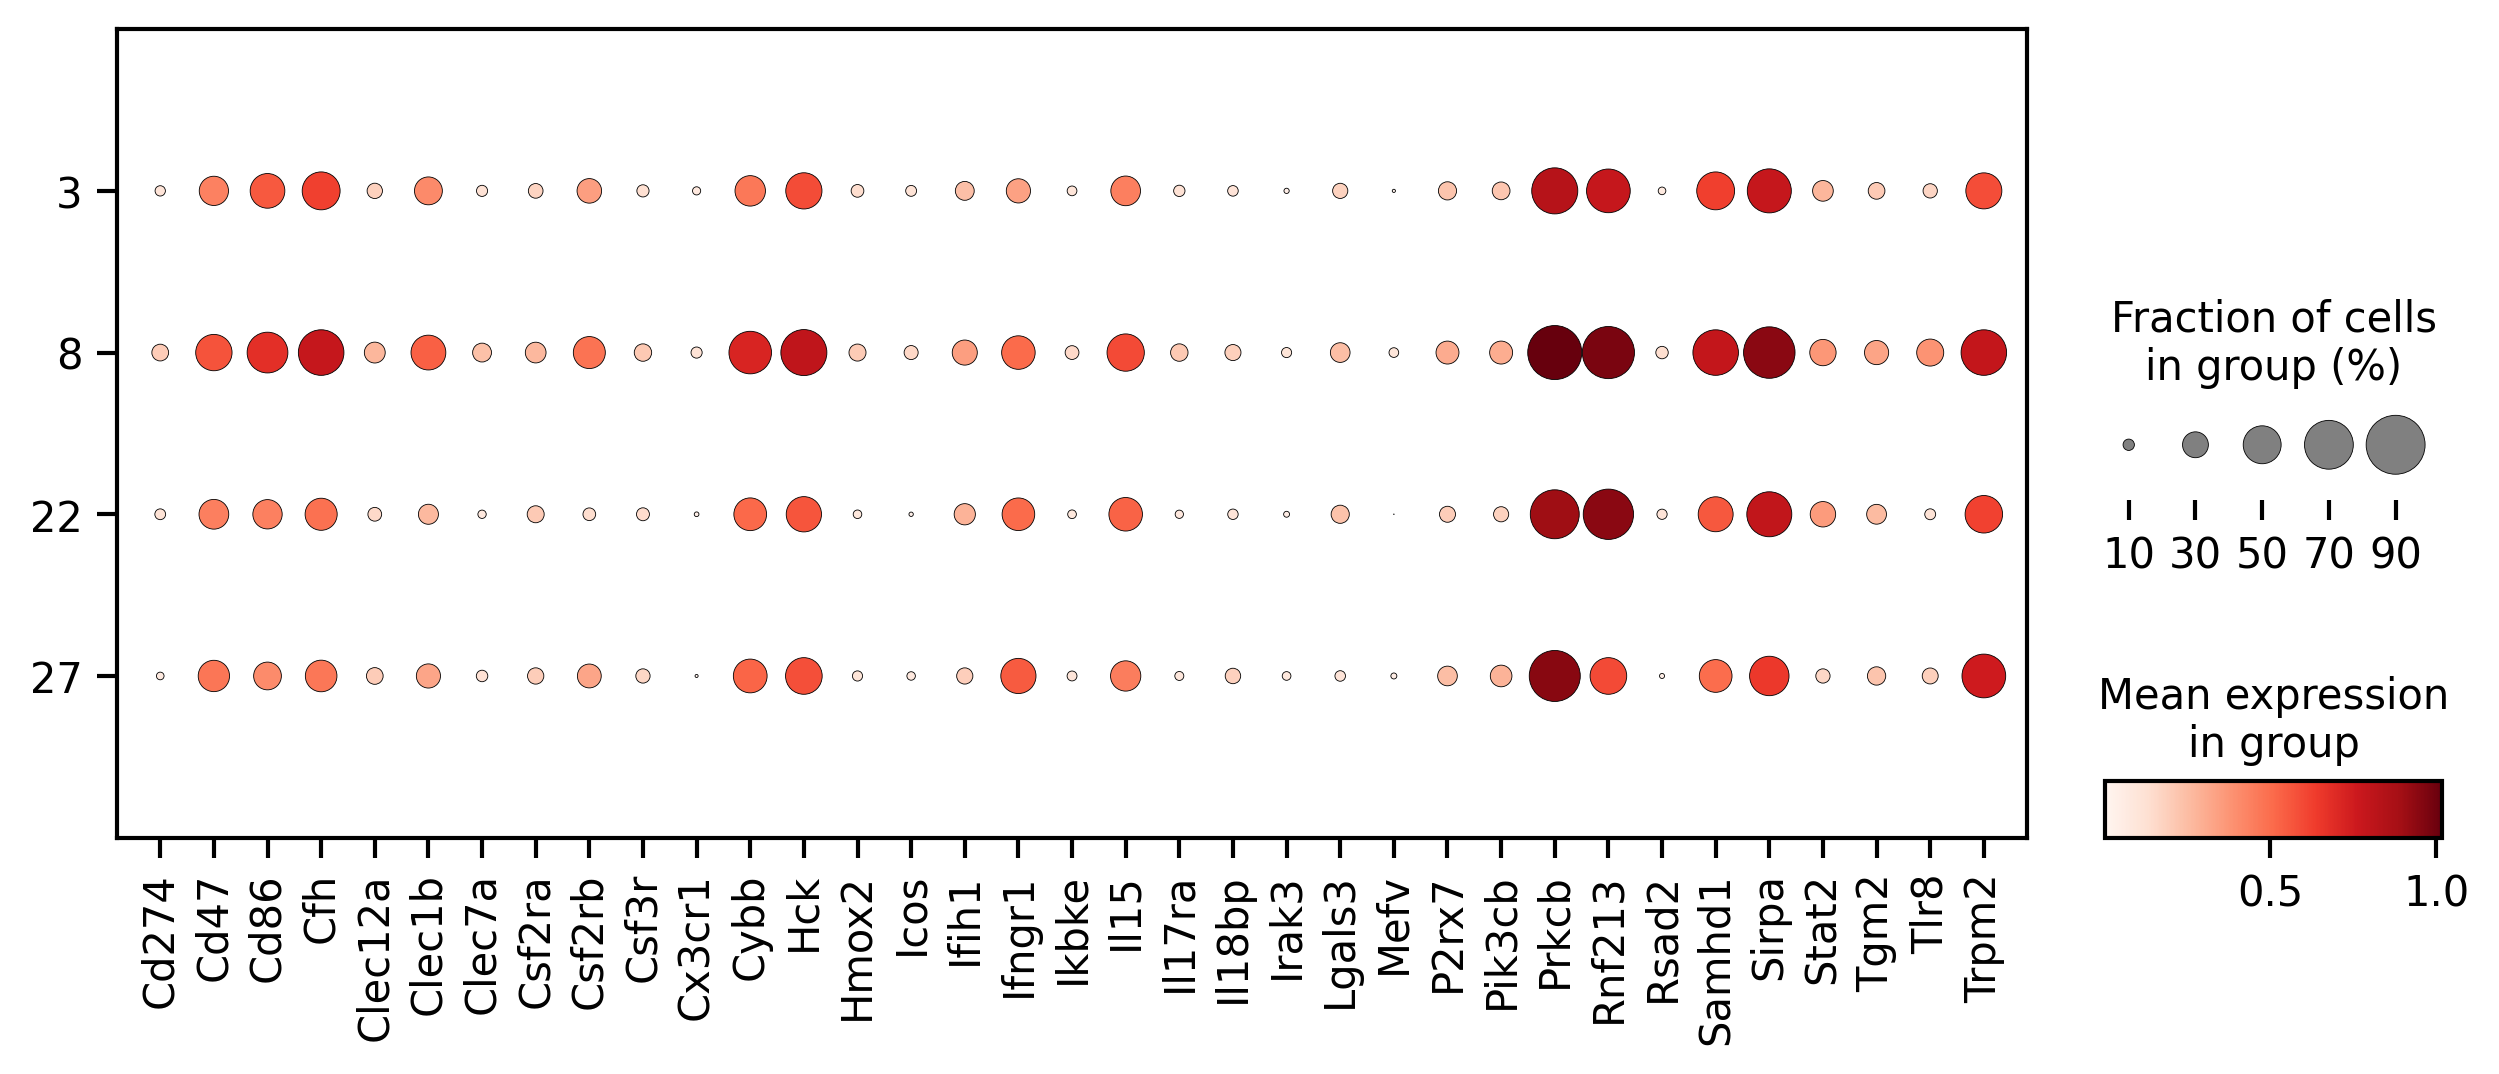

In [23]:
genes = [
    'Cd274', 'Cd47', 'Cd86', 'Cfh', 'Clec12a', 'Clec1b', 'Clec7a', 'Csf2ra', 'Csf2rb',
    'Csf3r', 'Cx3cr1', 'Cybb', 'Hck', 'Hmox2', 'Icos', 'Ifih1', 'Ifngr1', 'Ikbke',
    'Il15', 'Il17ra', 'Il18bp', 'Irak3', 'Lgals3', 'Mefv', 'P2rx7', 'Pik3cb', 'Prkcb',
    'Rnf213', 'Rsad2', 'Samhd1', 'Sirpa', 'Stat2', 'Tgm2', 'Tlr8', 'Trpm2'
]


sc.pl.dotplot(kc_adata, genes, 'leiden',
              #mean_only_expressed = True,
              figsize = (10,3.5),
              log = True,
              dendrogram=False)
